# Análise de Viagens a Serviço do Governo Federal

Este notebook apresenta análises realizadas sobre os dados tratados na camada Silver do projeto.

As análises incluem:

- gastos totais;
- órgãos com maior volume de viagens;
- destinos mais frequentes;
- duração média das viagens;
- meios de transporte mais utilizados;
- visualizações e conclusões.

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

import sys
from pathlib import Path

In [119]:
BASE_DIR = Path.cwd().parent

if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from config import DB_CONFIG

In [120]:
url_conexao = (
    f"postgresql+psycopg2://"
    f"{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}"
    f"/{DB_CONFIG['database']}"
)

engine = create_engine(url_conexao)

print("Conexão com PostgreSQL criada com sucesso!")

Conexão com PostgreSQL criada com sucesso!


In [121]:
def formatar_reais(valor):
    """
    Formata valores monetários para o padrão brasileiro.

    A função utiliza a formatação padrão do Python
    (1,234.56) e converte para:

    1.234,56

    Não depende da configuração regional do sistema
    operacional.
    """
    if pd.isna(valor):
        return ""

    return (
        f"R$ {valor:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )


def formatar_inteiro(valor):
    if pd.isna(valor) or valor == "":
        return ""
    try:
        return f"{int(float(valor)):,}".replace(",", ".")
    except (ValueError, TypeError):
        return str(valor)


def formatar_decimal(valor):
    if pd.isna(valor):
        return ""

    return (
        f"{valor:.2f}"
        .replace(".", ",")
    )

In [122]:
consulta = """
SELECT COUNT(*) AS total
FROM silver_viagem;
"""

with engine.connect() as conexao:
    df = pd.read_sql(consulta, con=conexao)

# 1. Visão Geral dos Dados

Nesta etapa são apresentados indicadores gerais da base de viagens a serviço do Governo Federal.

Os indicadores incluem:

- quantidade de viagens;
- gasto total;
- gasto médio por viagem;
- duração média das viagens.

In [123]:
consulta = """
SELECT
    COUNT(*) AS total_viagens,
    SUM(valor_total) AS gasto_total,
    ROUND(AVG(valor_total), 2) AS gasto_medio,
    ROUND(AVG(duracao_dias), 2) AS duracao_media
FROM silver_viagem;
"""

visao_geral = pd.read_sql(
    consulta,
    con=engine
)

visao_geral["total_viagens"] = (
    visao_geral["total_viagens"]
    .apply(formatar_inteiro)
)

visao_geral["gasto_total"] = (
    visao_geral["gasto_total"]
    .apply(formatar_reais)
)

visao_geral["gasto_medio"] = (
    visao_geral["gasto_medio"]
    .apply(formatar_reais)
)

visao_geral["duracao_media"] = (
    visao_geral["duracao_media"]
    .apply(lambda valor: f"{formatar_decimal(valor)} dias")
)

visao_geral.index = range(
    1,
    len(visao_geral) + 1
)

visao_geral

,total_viagens,gasto_total,gasto_medio,duracao_media
1,341.860,"R$ 1.200.760.089,85","R$ 3.512,43","7,06 dias"


### Conclusão

A base contém mais de 340 mil viagens oficiais registradas.

Os indicadores apresentados fornecem uma visão inicial do volume de viagens, dos gastos totais e da duração média dos deslocamentos realizados pelos órgãos públicos.

# 2. Órgãos com Maior Gasto em Viagens

Nesta etapa são identificados os órgãos públicos que concentraram os maiores gastos com viagens durante o período analisado.

In [124]:
consulta = """
SELECT
    nome_orgao_superior,
    SUM(valor_total) AS gasto_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY gasto_total DESC
LIMIT 10;
"""

top_orgaos = pd.read_sql(
    consulta,
    con=engine
)

top_orgaos.index = range(
    1,
    len(top_orgaos) + 1
)

top_orgaos_exibicao = top_orgaos.copy()

top_orgaos_exibicao["gasto_total"] = (
    top_orgaos_exibicao["gasto_total"]
    .apply(formatar_reais)
)

top_orgaos_exibicao

,nome_orgao_superior,gasto_total
1,Ministério da Justiça e Segurança Pública,"R$ 490.813.474,85"
2,Ministério da Defesa,"R$ 157.059.698,59"
3,Ministério da Educação,"R$ 112.519.456,96"
4,Ministério do Meio Ambiente e Mudança do Clima,"R$ 50.548.377,44"
5,Ministério da Previdência Social,"R$ 40.921.476,10"
6,Ministério da Saúde,"R$ 39.986.010,45"
7,Ministério da Fazenda,"R$ 32.857.642,63"
8,Ministério dos Povos Indígenas,"R$ 26.595.369,03"
9,Ministério das Relações Exteriores,"R$ 25.915.125,36"
10,Ministério do Desenvolvimento Agrário e Agricu...,"R$ 22.344.944,73"


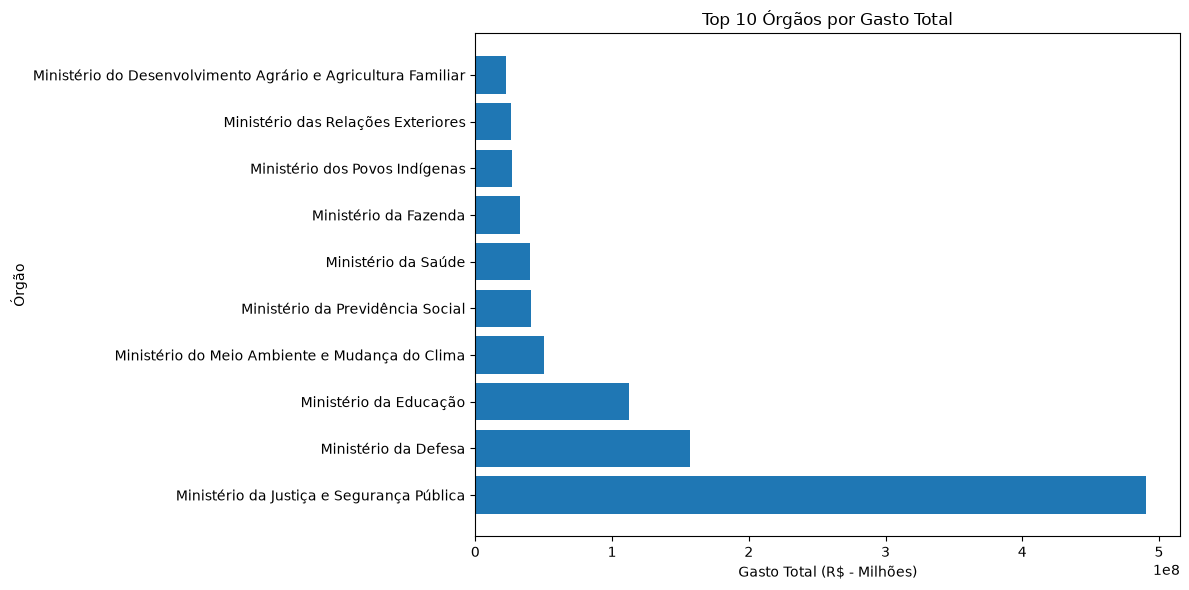

In [125]:
plt.figure(figsize=(12,6))

plt.barh(
    top_orgaos["nome_orgao_superior"],
    top_orgaos["gasto_total"]
)

plt.xlabel("Gasto Total (R$ - Milhões)")
plt.ylabel("Órgão")
plt.title("Top 10 Órgãos por Gasto Total")

plt.tight_layout()

plt.show()

### Conclusão

Observa-se que poucos órgãos concentram a maior parte dos gastos com viagens oficiais.

Esse comportamento pode estar relacionado ao volume de servidores, à abrangência nacional das atividades e à necessidade frequente de deslocamentos institucionais.

# 3. Meio de Transporte Menos Utilizado

Esta análise identifica o meio de transporte com menor quantidade de registros na tabela de trechos.

In [126]:
consulta = """
SELECT
    meio_transporte,
    COUNT(*) AS quantidade_trechos
FROM silver_trecho
GROUP BY meio_transporte
ORDER BY quantidade_trechos ASC;
"""

transportes = pd.read_sql(
    consulta,
    con=engine
)

transportes.index = range(
    1,
    len(transportes) + 1
)

transportes_exibicao = transportes.copy()

transportes_exibicao["quantidade_trechos"] = (
    transportes_exibicao["quantidade_trechos"]
    .apply(formatar_inteiro)
)

transportes_exibicao

,meio_transporte,quantidade_trechos
1,Marítimo,481
2,Ferroviário,874
3,Fluvial,8.429
4,Inválido,26.659
5,Veículo Próprio,42.846
6,Rodoviário,64.970
7,Aéreo,232.666
8,Veículo Oficial,386.424


In [127]:
transporte_menos_usado = transportes.iloc[0]

print(
    f"O meio de transporte menos utilizado foi "
    f"{transporte_menos_usado['meio_transporte']}, "
    f"com {formatar_inteiro(transporte_menos_usado['quantidade_trechos'])} "
    f"trechos registrados."
)

O meio de transporte menos utilizado foi Marítimo, com 481 trechos registrados.


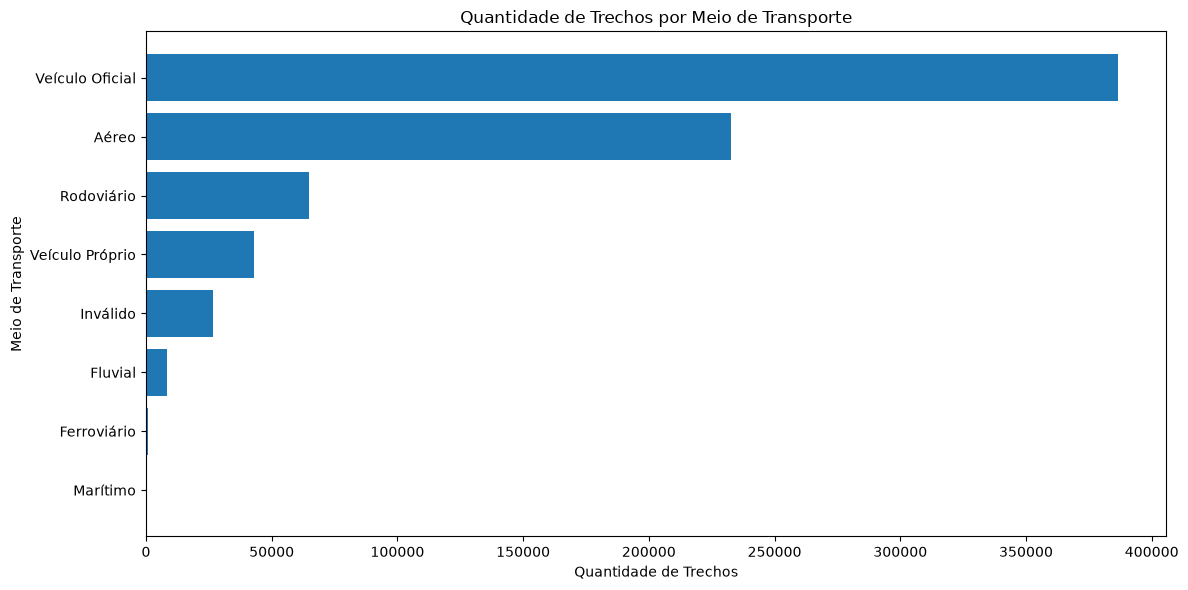

In [128]:
plt.figure(figsize=(12, 6))

plt.barh(
    transportes["meio_transporte"],
    transportes["quantidade_trechos"]
)

plt.xlabel("Quantidade de Trechos")
plt.ylabel("Meio de Transporte")
plt.title("Quantidade de Trechos por Meio de Transporte")
plt.tight_layout()
plt.show()

### Conclusão

O meio de transporte menos utilizado foi **o marítimo**, considerando a quantidade de registros encontrados na camada Silver de trechos.

# 4. Meio de Transporte Mais Utilizado nos Trechos

Nesta análise é identificado o meio de transporte predominante nos deslocamentos registrados.

In [129]:
transporte_mais_usado = (
    transportes
    .sort_values(
        by="quantidade_trechos",
        ascending=False
    )
    .head(1)
    .copy()
)

transporte_mais_usado.index = [1]

transporte_mais_usado["quantidade_trechos"] = (
    transporte_mais_usado["quantidade_trechos"]
    .apply(formatar_inteiro)
)

transporte_mais_usado

,meio_transporte,quantidade_trechos
1,Veículo Oficial,386.424


### Conclusão

O meio de transporte mais utilizado foi **o Veículo Oficial**, indicando sua predominância nos deslocamentos realizados durante o período analisado.

# 5. Viagem de Maior Duração

Esta análise identifica a viagem com maior duração em dias e apresenta o seu custo total.

In [130]:
consulta = """
SELECT
    v.id_viagem,
    v.num_proposta,
    v.nome_viajante,
    v.nome_orgao_superior,
    v.data_inicio,
    v.data_fim,
    v.duracao_dias,
    v.destinos,
    v.valor_total AS valor_informado_viagem,
    COALESCE(SUM(p.valor), 0) AS valor_total_pago
FROM silver_viagem v
LEFT JOIN silver_pagamento p
    ON v.id_viagem = p.id_viagem
GROUP BY
    v.id_viagem,
    v.num_proposta,
    v.nome_viajante,
    v.nome_orgao_superior,
    v.data_inicio,
    v.data_fim,
    v.duracao_dias,
    v.destinos,
    v.valor_total
ORDER BY
    v.duracao_dias DESC,
    valor_total_pago DESC
LIMIT 10;
"""

viagens_mais_longas = pd.read_sql(
    consulta,
    con=engine
)

viagens_mais_longas["valor_informado_viagem"] = (
    viagens_mais_longas["valor_informado_viagem"]
    .apply(formatar_reais)
)

viagens_mais_longas["valor_total_pago"] = (
    viagens_mais_longas["valor_total_pago"]
    .apply(formatar_reais)
)

viagens_mais_longas["duracao_dias"] = (
    viagens_mais_longas["duracao_dias"]
    .apply(lambda x: f"{formatar_inteiro(x)} dias")
)

viagens_mais_longas.index = range(
    1,
    len(viagens_mais_longas) + 1
)

viagens_mais_longas

,id_viagem,num_proposta,nome_viajante,nome_orgao_superior,data_inicio,data_fim,duracao_dias,destinos,valor_informado_viagem,valor_total_pago
1,20699856,000428/25-4C,LUISANGELA CORREA FRANCO DE FARIA,Ministério da Previdência Social,2025-01-13,2026-01-31,383 dias,Mogi Mirim/SP,"R$ 0,00","R$ 0,00"
2,20793594,Informações p,Informações protegidas por sigilo,Ministério da Justiça e Segurança Pública,2025-01-02,2026-01-15,378 dias,Informações protegidas por sigilo,"R$ 120.650,00","R$ 120.650,00"
3,20793492,Informações p,Informações protegidas por sigilo,Ministério da Justiça e Segurança Pública,2025-01-11,2026-01-15,369 dias,Informações protegidas por sigilo,"R$ 113.382,50","R$ 113.382,50"
4,20774569,000028/25,CLAUDIA ADRIANA DA SILVA,Ministério da Educação,2025-02-26,2026-03-02,369 dias,Bariloche/Argentina,"R$ 0,00","R$ 0,00"
5,20592696,001082/25-11C,RAILANA BERENICE AMORAS OLIVEIRA,Ministério da Justiça e Segurança Pública,2025-01-01,2026-01-02,366 dias,"Brasília/DF, Belo Horizonte/MG, Brasília/DF, F...","R$ 159.044,90","R$ 159.044,90"
6,20685666,001289/25-13C,STEFANO DOS SANTOS NUNES,Ministério da Justiça e Segurança Pública,2025-01-01,2026-01-02,366 dias,"Brasília/DF, Brasília/DF, Rio de Janeiro/RJ, B...","R$ 124.312,50","R$ 124.312,50"
7,20732132,000142/25,GILBERTO SANTOS ANDRADE,Ministério da Educação,2025-03-31,2026-03-31,365 dias,Angers/França,"R$ 0,00","R$ 0,00"
8,20589962,000005/25-2C,BRUNO WANDERLEY FRANCA,Ministério da Educação,2025-02-23,2026-02-23,365 dias,Aberdeen/Reino Unido,"R$ 0,00","R$ 0,00"
9,20557147,000836/25-26C,JULYANA DOS SANTOS COELHO,Ministério da Justiça e Segurança Pública,2025-01-01,2025-12-31,364 dias,"Brasília/DF, Rio Branco/AC, Cruzeiro do Sul/AC...","R$ 216.729,36","R$ 216.729,36"
10,20649880,001382/25-19C,BRUNO REZENDE CABRAL,Ministério da Justiça e Segurança Pública,2025-01-01,2025-12-31,364 dias,"Brasília/DF, Rio de Janeiro/RJ, Angra dos Reis...","R$ 207.220,14","R$ 207.220,14"


In [131]:
viagem_mais_longa = viagens_mais_longas.head(1)

viagem_mais_longa.index = [1]

viagem_mais_longa

,id_viagem,num_proposta,nome_viajante,nome_orgao_superior,data_inicio,data_fim,duracao_dias,destinos,valor_informado_viagem,valor_total_pago
1,20699856,000428/25-4C,LUISANGELA CORREA FRANCO DE FARIA,Ministério da Previdência Social,2025-01-13,2026-01-31,383 dias,Mogi Mirim/SP,"R$ 0,00","R$ 0,00"


### Conclusão

A viagem de maior duração teve **383 dias**, entre janeiro de 2025 e janeiro de 2026.

Tanto o valor informado na tabela de viagens quanto o total localizado na tabela de pagamentos foram de **R$ 0,00**. Esse resultado deve ser interpretado com cautela, pois pode representar ausência de registro financeiro, viagem sem custo lançado ou limitação da fonte original.

O registro pertence à proposta **000428/25-4C** e teve como destino **Mogi Mirim/SP**.

# 6. Destinos Mais Frequentes

Nesta análise são identificados os destinos que receberam o maior número de viagens durante o período analisado.

In [132]:
consulta = """
SELECT
    destinos,
    COUNT(*) AS quantidade_viagens
FROM silver_viagem
WHERE destinos IS NOT NULL
GROUP BY destinos
ORDER BY quantidade_viagens DESC
LIMIT 10;
"""

top_destinos = pd.read_sql(
    consulta,
    con=engine
)

top_destinos_formatado = top_destinos.copy()

top_destinos_formatado["quantidade_viagens"] = (
    top_destinos_formatado["quantidade_viagens"]
    .apply(lambda x: f"{x:,}")
    .str.replace(",", ".")
)

top_destinos_formatado.index = range(
    1,
    len(top_destinos_formatado) + 1
)

top_destinos_formatado

,destinos,quantidade_viagens
1,Informações protegidas por sigilo,51.601
2,Brasília/DF,25.419
3,São Paulo/SP,11.621
4,Rio de Janeiro/RJ,11.563
5,São José dos Campos/SP,6.182
6,Belo Horizonte/MG,4.257
7,Curitiba/PR,3.887
8,Recife/PE,3.637
9,Manaus/AM,3.306
10,Salvador/BA,3.202


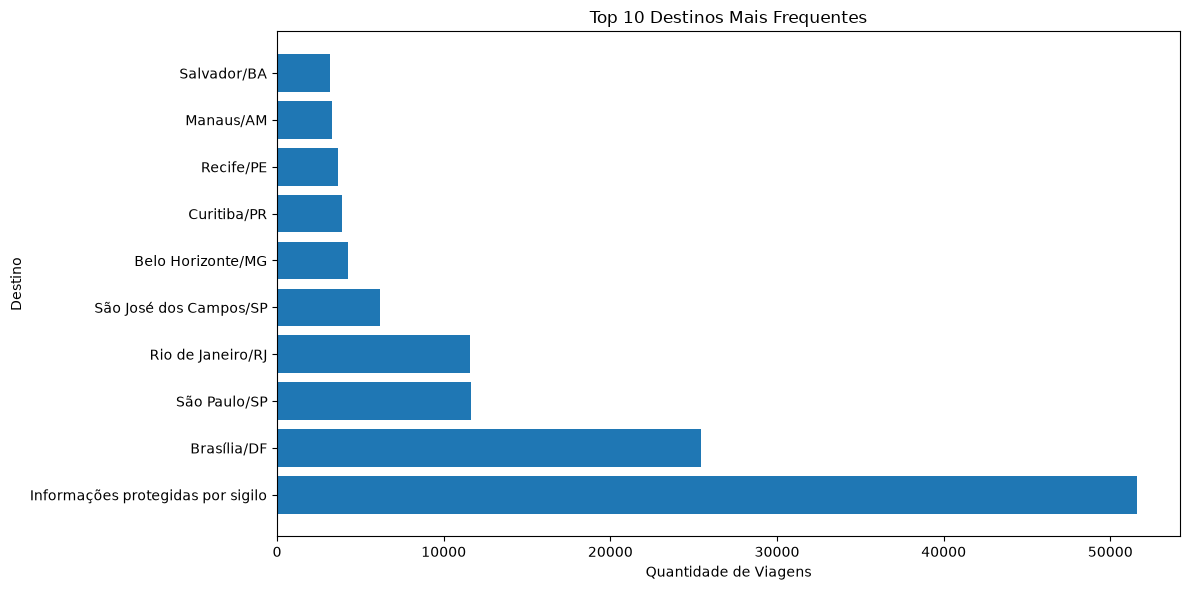

In [133]:
plt.figure(figsize=(12,6))

plt.barh(
    top_destinos["destinos"],
    top_destinos["quantidade_viagens"]
)

plt.xlabel("Quantidade de Viagens")
plt.ylabel("Destino")
plt.title("Top 10 Destinos Mais Frequentes")

plt.tight_layout()

plt.show()

### Conclusão

Os destinos apresentados concentram grande parte das viagens oficiais realizadas pelos órgãos públicos, indicando regiões com maior demanda por deslocamentos institucionais. Porém, grande parte dessas viagens são protegidas por sigilo. 

# 7. Órgãos com Maior Quantidade de Viagens

Nesta etapa é analisado quais órgãos realizaram o maior número de viagens durante o período.

In [134]:
consulta = """
SELECT
    nome_orgao_superior,
    COUNT(*) AS quantidade_viagens
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY quantidade_viagens DESC
LIMIT 10;
"""

orgaos_viagens = pd.read_sql(
    consulta,
    con=engine
)

orgaos_viagens.index = range(
    1,
    len(orgaos_viagens) + 1
)

orgaos_viagens_exibicao = orgaos_viagens.copy()

orgaos_viagens_exibicao["quantidade_viagens"] = (
    orgaos_viagens_exibicao["quantidade_viagens"]
    .apply(formatar_inteiro)
)

orgaos_viagens_exibicao

,nome_orgao_superior,quantidade_viagens
1,Ministério da Justiça e Segurança Pública,75.742
2,Ministério da Educação,65.295
3,Ministério da Defesa,61.912
4,Ministério do Meio Ambiente e Mudança do Clima,19.413
5,Ministério do Planejamento e Orçamento,18.172
6,Sem informação,14.768
7,Ministério da Fazenda,11.854
8,Ministério da Saúde,8.672
9,Ministério do Desenvolvimento Agrário e Agricu...,8.581
10,Ministério da Previdência Social,8.190


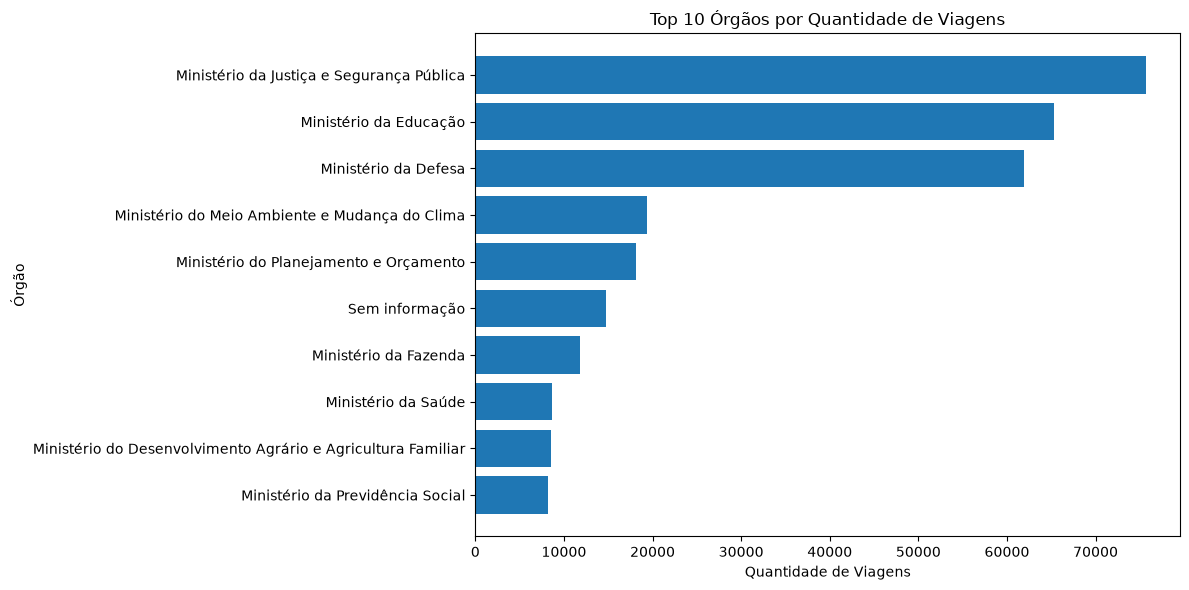

In [135]:
plt.figure(figsize=(12, 6))

plt.barh(
    orgaos_viagens["nome_orgao_superior"],
    orgaos_viagens["quantidade_viagens"]
)

plt.xlabel("Quantidade de Viagens")
plt.ylabel("Órgão")
plt.title("Top 10 Órgãos por Quantidade de Viagens")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Conclusão

Os órgãos apresentados concentram o maior volume de deslocamentos oficiais, refletindo a natureza de suas atividades e sua atuação em âmbito nacional.

# 8. Evolução Mensal dos Gastos

Esta análise apresenta a evolução dos gastos com viagens oficiais ao longo dos meses.

In [136]:
consulta = """
SELECT
    DATE_TRUNC('month', data_inicio) AS mes,
    SUM(valor_total) AS gasto_total
FROM silver_viagem
GROUP BY mes
ORDER BY mes;
"""

gastos_mes = pd.read_sql(
    consulta,
    con=engine
)

gastos_mes_grafico = gastos_mes.copy()

gastos_mes["mes"] = pd.to_datetime(
    gastos_mes["mes"]
).dt.strftime("%m/%Y")

gastos_mes["gasto_total"] = (
    gastos_mes["gasto_total"]
    .apply(formatar_reais)
)

gastos_mes.index = gastos_mes.index + 1

gastos_mes

,mes,gasto_total
1,01/2025,"R$ 289.694.346,54"
2,02/2025,"R$ 119.876.810,06"
3,03/2025,"R$ 205.629.980,83"
4,04/2025,"R$ 170.445.840,17"
5,05/2025,"R$ 209.867.223,56"
6,06/2025,"R$ 205.245.888,69"


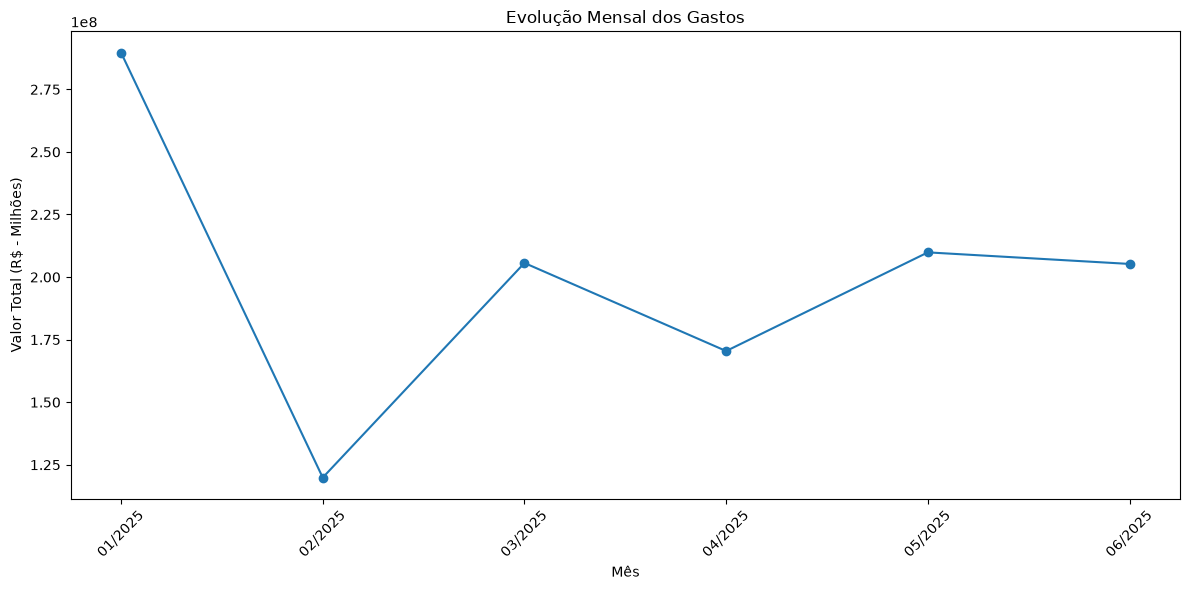

In [137]:
gastos_mes_grafico["mes"] = pd.to_datetime(
    gastos_mes_grafico["mes"]
).dt.strftime("%m/%Y")

plt.figure(figsize=(12, 6))

plt.plot(
    gastos_mes_grafico["mes"],
    gastos_mes_grafico["gasto_total"],
    marker="o"
)

plt.title("Evolução Mensal dos Gastos")
plt.xlabel("Mês")
plt.ylabel("Valor Total (R$ - Milhões)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Conclusão

A evolução mensal permite identificar períodos de maior e menor volume de gastos, auxiliando no acompanhamento orçamentário e no planejamento das viagens institucionais.

# Conclusões Gerais

A análise dos dados permitiu identificar padrões relevantes sobre as viagens a serviço do Governo Federal.

Os principais resultados obtidos foram:

- identificação dos órgãos com maiores gastos;
- identificação dos órgãos com maior número de viagens;
- meios de transporte mais e menos utilizados;
- destinos mais frequentes;
- viagem de maior duração;
- evolução mensal dos gastos públicos.

O desenvolvimento deste projeto contemplou todas as etapas de um pipeline ETL, incluindo extração automatizada, tratamento dos dados, armazenamento em banco PostgreSQL, modelagem em camadas (Raw e Silver) e análise exploratória utilizando SQL, Python, Pandas e Matplotlib.

# Encerramento

Ao final das análises, a conexão com o banco de dados é encerrada para liberar os recursos utilizados pelo SQLAlchemy.

In [138]:
engine.dispose()

print("✅ Conexão com o PostgreSQL encerrada com sucesso.")

✅ Conexão com o PostgreSQL encerrada com sucesso.
